# Differential Gene Expression — Conditions

Pseudobulk DEG following the [sc-best-practices tutorial](https://www.sc-best-practices.org/conditions/differential_gene_expression.html), using **decoupler** (`dc.pp.pseudobulk`, `dc.pp.filter_samples`, `dc.pp.filter_by_expr`) for pseudobulk aggregation and gene filtering, then PyDESeq2 for testing.

**Comparisons (cohort design from Pekayvaz et al. 2024; DESeq2 pseudobulk analysis is our own):**
1. ACS vs CCS — sterile ACS, all timepoints (TP1M–TP4M) vs CCS, blocked by patient (`~ patient_id + condition`) — beyond the tutorial's baseline, since ACS patients contribute up to 4 correlated timepoint samples. Pekayvaz et al. handle the same repeated-measures problem via mixed-effects models (cross-timepoint outcome comparisons) or by testing timepoints separately (CCS baseline comparisons); this is the pseudobulk-DE equivalent.
2. ACS vs non-CCS — sterile ACS (TP1M) vs non-CCS + Sclerosis, pooled as Control (not a comparison the paper makes)
3. ACS longitudinal: TP1M (acute) vs TP4M (pre-discharge), paired within-patient (`~ patient_id + timepoint`) — immune resolution

**Run across cell-type groupings — Harmony and DRVI only:** Scanorama is not run as a separate method here — it's only ever the source of the named labels. For each of Harmony and DRVI, run the pipeline twice: once on that integration's **own raw Leiden clusters already in the working object** (`harmony_leiden`: 25 clusters, `drvi_leiden`: 32 clusters — not recomputed), and once on the **Scanorama-transferred named cell types** for those same clusters.

In [1]:
DATA_PATH  = "/vol/disk/ubuntu/master_practicum_cytokines/repo/Mapra_Cytokines/data/data_for_practicum_post_integration.h5ad"
OUTPUT_DIR = "/vol/disk/ubuntu/master_practicum_cytokines/lisa/deg_conditions"

# Reference cell-type annotation: the only manually annotated column. Used for the
# cohort-overview plots below and as the label source for Step 1b's label transfer.
CELL_TYPE_COL = "cell_type_Scanorama"

# Cell type annotations to run the DEG comparison pipeline on. We only compare
# Harmony and DRVI (Scanorama is not a separate method here, only the label source).
# For each, run both the raw Leiden clusters already in the working object
# (harmony_leiden, drvi_leiden -- not recomputed) and the Scanorama-transferred
# named types for those same clusters (cell_type_Harmony, cell_type_DRVI; Step 1b).
CELL_TYPE_COLS = {
    "Harmony_leiden": "harmony_leiden",
    "Harmony_named":  "cell_type_Harmony",
    "DRVI_leiden":    "drvi_leiden",
    "DRVI_named":     "cell_type_DRVI",
}

SAMPLE_COL    = "display_name"    # unique patient-timepoint ID (e.g. "2.1", "2.4", "29")
CONDITION_COL = "classification"  # ACS / CCS / non-CCS
TIMEPOINT_COL = "timepoint"       # derived below from display_name suffix

PADJ_THRESH = 0.05
LFC_THRESH  = 1.0

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output: {OUTPUT_DIR}")

Output: /vol/disk/ubuntu/master_practicum_cytokines/lisa/deg_conditions


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import decoupler as dc
from scipy.sparse import issparse

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)

## Step 1 — Load data and inspect metadata

In [3]:
adata = sc.read_h5ad(DATA_PATH)
print(f"Cells: {adata.n_obs:,}   Genes: {adata.n_vars:,}")

print("\nCondition counts:")
print(adata.obs[CONDITION_COL].value_counts().to_string())

print("\nSamples per condition:")
print(adata.obs.groupby(CONDITION_COL)[SAMPLE_COL].nunique().to_string())

print("\nCell types (Scanorama, reference annotation):")
print(adata.obs[CELL_TYPE_COL].value_counts().to_string())

print(f"\nharmony_leiden: {adata.obs['harmony_leiden'].nunique()} clusters")
print(f"drvi_leiden: {adata.obs['drvi_leiden'].nunique()} clusters")

Cells: 109,504   Genes: 19,220

Condition counts:
classification
acs_w_o_infection            60712
ccs                          12566
vollstaendiger_ausschluss    11372
acs_subacute                  9903
acs_w_infection               9734
koronarsklerose               5217

Samples per condition:
classification
acs_subacute                  9
acs_w_infection              15
acs_w_o_infection            62
ccs                          16
koronarsklerose               7
vollstaendiger_ausschluss    10

Cell types (Scanorama, reference annotation):
cell_type_Scanorama
T-cell-CD4                 52875
Monocytes - CD14           17784
T-cell-CD8                 13666
NK                         13095
B-cell                      6934
Monocytes - CD16_FCGR3A     2861
Dendritic                    989
Plasma Blast                 729
Other                        268
Progenitor                   243
Megakaryocytes                60

harmony_leiden: 25 clusters
drvi_leiden: 32 clusters


In [4]:
def parse_timepoint(display_name):
    s = str(display_name)
    if "." not in s:
        return "TP0M"
    return f"TP{s.split('.')[-1]}M"

adata.obs["timepoint"] = adata.obs["display_name"].apply(parse_timepoint)

condition_map = {
    "acs_w_o_infection":         "ACS_sterile",
    "acs_w_infection":           "ACS_infection",
    "acs_subacute":              "ACS_subacute",
    "ccs":                       "CCS",
    "vollstaendiger_ausschluss": "non-CCS",
    "koronarsklerose":           "Sclerosis",
}
adata.obs["condition"] = adata.obs[CONDITION_COL].map(condition_map)

print("Timepoint distribution:")
print(adata.obs["timepoint"].value_counts().to_string())

print("\nCondition:")
print(adata.obs["condition"].value_counts().to_string())

print("\nTimepoint x condition:")
display(pd.crosstab(adata.obs["timepoint"], adata.obs["condition"]))

Timepoint distribution:
timepoint
TP0M    29155
TP2M    24873
TP1M    21258
TP3M    17915
TP4M    16303

Condition:
condition
ACS_sterile      60712
CCS              12566
non-CCS          11372
ACS_subacute      9903
ACS_infection     9734
Sclerosis         5217

Timepoint x condition:


condition,ACS_subacute,ACS_infection,ACS_sterile,CCS,Sclerosis,non-CCS
timepoint,,,,,,
TP0M,0,0,0,12566,5217,11372
TP1M,3476,2164,15618,0,0,0
TP2M,2405,1630,20838,0,0,0
TP3M,2533,3482,11900,0,0,0
TP4M,1489,2458,12356,0,0,0


## Step 1b — Derive named cell types for Harmony and DRVI

Only `cell_type_Scanorama` is manually annotated. Harmony (`harmony_leiden`) and DRVI (`drvi_leiden`) only have unlabeled Leiden clusters already computed in the working object. Each cluster is assigned the majority `cell_type_Scanorama` label among its cells (label transfer). Cluster purity (fraction of cells in a cluster carrying the assigned majority label) is reported as a sanity check.

In [5]:
def transfer_celltype_labels(adata, source_col, cluster_col, new_col):
    """Assign each cluster in `cluster_col` the majority `source_col` label; store in `new_col`."""
    majority = adata.obs.groupby(cluster_col, observed=True)[source_col].agg(lambda s: s.value_counts().idxmax())
    adata.obs[new_col] = adata.obs[cluster_col].map(majority).astype("category")

    match = adata.obs[source_col] == adata.obs[cluster_col].map(majority)
    purity = match.groupby(adata.obs[cluster_col], observed=True).mean()

    print(f"{new_col}: {adata.obs[new_col].nunique()} cell types mapped from "
          f"{adata.obs[cluster_col].nunique()} '{cluster_col}' clusters")
    print(f"Mean cluster purity vs '{source_col}': {purity.mean():.1%}  (worst cluster: {purity.min():.1%})")
    return adata


transfer_celltype_labels(adata, source_col=CELL_TYPE_COL, cluster_col="harmony_leiden", new_col="cell_type_Harmony")
transfer_celltype_labels(adata, source_col=CELL_TYPE_COL, cluster_col="drvi_leiden", new_col="cell_type_DRVI")

print("\ncell_type_Harmony counts:")
print(adata.obs["cell_type_Harmony"].value_counts().to_string())
print("\ncell_type_DRVI counts:")
print(adata.obs["cell_type_DRVI"].value_counts().to_string())

cell_type_Harmony: 9 cell types mapped from 25 'harmony_leiden' clusters
Mean cluster purity vs 'cell_type_Scanorama': 94.6%  (worst cluster: 69.4%)
cell_type_DRVI: 9 cell types mapped from 32 'drvi_leiden' clusters
Mean cluster purity vs 'cell_type_Scanorama': 90.0%  (worst cluster: 52.9%)

cell_type_Harmony counts:
cell_type_Harmony
T-cell-CD4                 53070
Monocytes - CD14           17593
NK                         13853
T-cell-CD8                 12997
B-cell                      6917
Monocytes - CD16_FCGR3A     2866
Dendritic                   1157
Plasma Blast                 718
Progenitor                   333
Megakaryocytes                 0
Other                          0

cell_type_DRVI counts:
cell_type_DRVI
T-cell-CD4                 54441
Monocytes - CD14           16865
NK                         14348
T-cell-CD8                 11210
B-cell                      6952
Monocytes - CD16_FCGR3A     3429
Dendritic                   1284
Plasma Blast                 7

In [ ]:
# ── Plot 1: Study design timeline ────────────────────────────────────────────
# ACS patients: 4 longitudinal timepoints; CCS/non-CCS: single draw

condition_order = ["ACS_sterile", "ACS_infection", "ACS_subacute", "CCS", "non-CCS", "Sclerosis"]
timepoints_acs  = ["TP1M", "TP2M", "TP3M", "TP4M"]
timepoints_ctrl = ["TP0M"]

tp_x = {"TP0M": 0, "TP1M": 1, "TP2M": 2, "TP3M": 3, "TP4M": 4}
tp_labels = {0: "Single\ndraw", 1: "TP1\n(peri-\ninterv.)", 2: "TP2\n(~14h)", 3: "TP3\n(~60h)", 4: "TP4\n(pre-\ndischarge)"}

colors_cond = {
    "ACS_sterile":   "#d62728",
    "ACS_infection": "#ff7f0e",
    "ACS_subacute":  "#e377c2",
    "CCS":           "#1f77b4",
    "non-CCS":       "#2ca02c",
    "Sclerosis":     "#17becf",
}

# Count patients per (condition, timepoint)
obs_unique = adata.obs[["condition", "timepoint", "display_name"]].drop_duplicates("display_name")
pt_counts = obs_unique.groupby(["condition", "timepoint"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(9, 4.5))

y_positions = {c: i for i, c in enumerate(reversed(condition_order))}
labels_shown = set()

for _, row in pt_counts.iterrows():
    cond, tp, n = row["condition"], row["timepoint"], row["n"]
    if cond not in y_positions or tp not in tp_x:
        continue
    y = y_positions[cond]
    x = tp_x[tp]
    color = colors_cond.get(cond, "grey")
    ax.scatter(x, y, s=n * 30, color=color, zorder=3, alpha=0.85,
               label=cond if cond not in labels_shown else "")
    ax.text(x, y, str(n), ha="center", va="center", fontsize=7.5,
            color="white", fontweight="bold")
    labels_shown.add(cond)

# Draw lines connecting ACS timepoints
for cond in ["ACS_sterile", "ACS_infection", "ACS_subacute"]:
    y = y_positions[cond]
    xs = [tp_x[tp] for tp in timepoints_acs
          if pt_counts[(pt_counts.condition == cond) & (pt_counts.timepoint == tp)].shape[0] > 0]
    if xs:
        ax.plot(xs, [y] * len(xs), color=colors_cond[cond], linewidth=1.5,
                alpha=0.5, zorder=2)

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(reversed(condition_order)), fontsize=10)
ax.set_xticks(list(tp_labels.keys()))
ax.set_xticklabels(list(tp_labels.values()), fontsize=9)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Timepoint", fontsize=11)
ax.set_title("Study design: samples per condition and timepoint\n(bubble size = number of patients)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "study_design_timeline.png"), bbox_inches="tight", dpi=150)
plt.show()

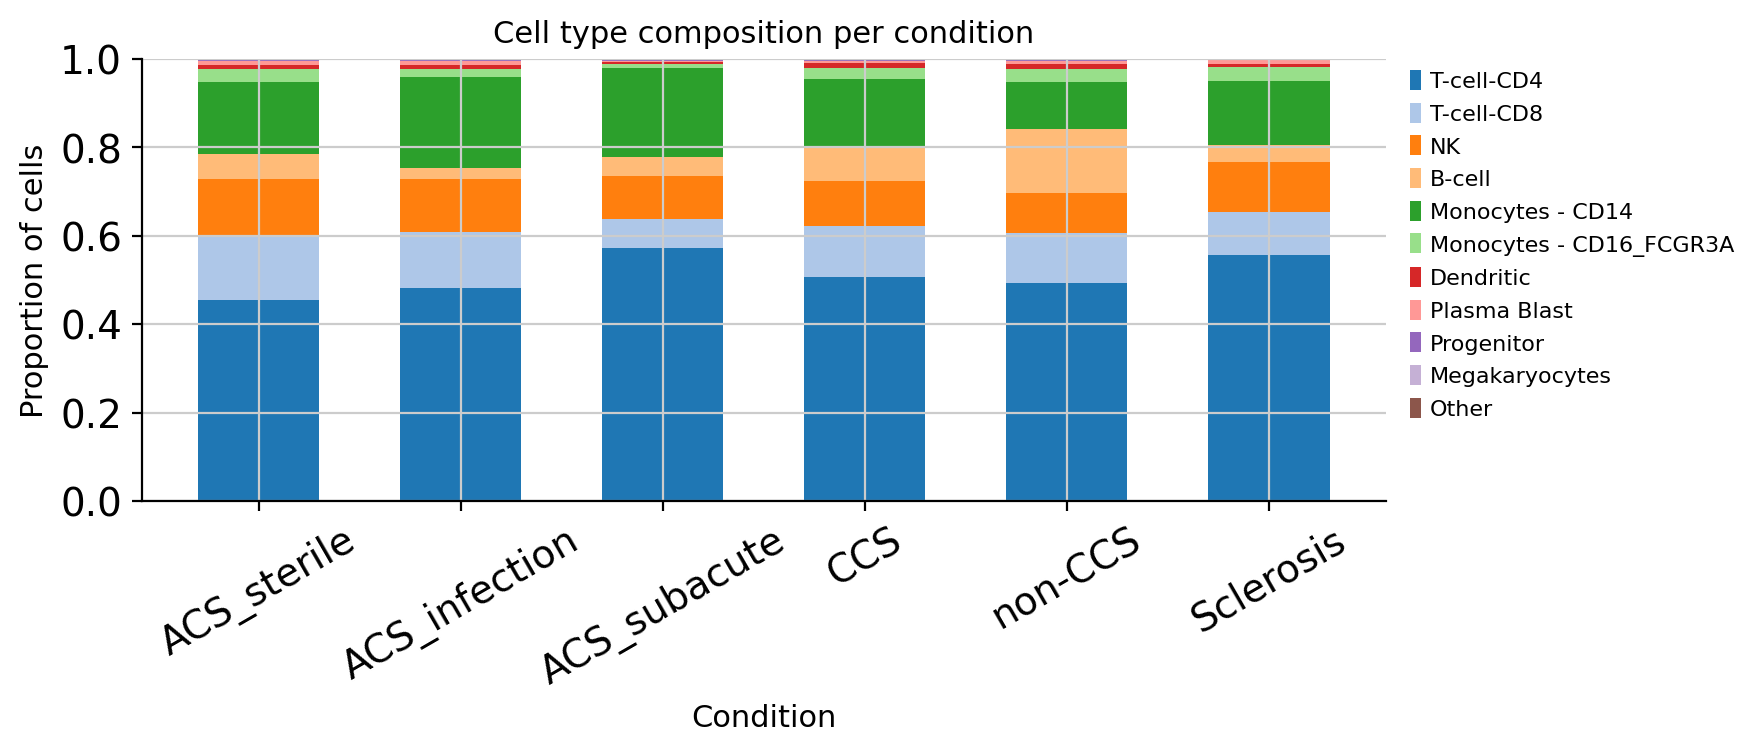

In [7]:
# ── Plot 2: Cell type composition per condition ───────────────────────────────
ct_order = [
    "T-cell-CD4", "T-cell-CD8", "NK", "B-cell",
    "Monocytes - CD14", "Monocytes - CD16_FCGR3A",
    "Dendritic", "Plasma Blast", "Progenitor", "Megakaryocytes", "Other"
]
ct_colors = plt.cm.tab20.colors[:len(ct_order)]

# Proportion of each cell type within each condition
ct_prop = (
    adata.obs.groupby(["condition", CELL_TYPE_COL])
             .size()
             .unstack(fill_value=0)
)
ct_prop = ct_prop.div(ct_prop.sum(axis=1), axis=0)
ct_prop = ct_prop.reindex(columns=[c for c in ct_order if c in ct_prop.columns])
ct_prop = ct_prop.reindex(condition_order)

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(ct_prop))

for i, ct in enumerate(ct_prop.columns):
    vals = ct_prop[ct].values
    ax.bar(ct_prop.index, vals, bottom=bottom,
           color=ct_colors[i], label=ct, width=0.6)
    bottom += vals

ax.set_ylabel("Proportion of cells", fontsize=11)
ax.set_xlabel("Condition", fontsize=11)
ax.set_title("Cell type composition per condition", fontsize=11)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "celltype_composition.png"), bbox_inches="tight", dpi=150)
plt.show()

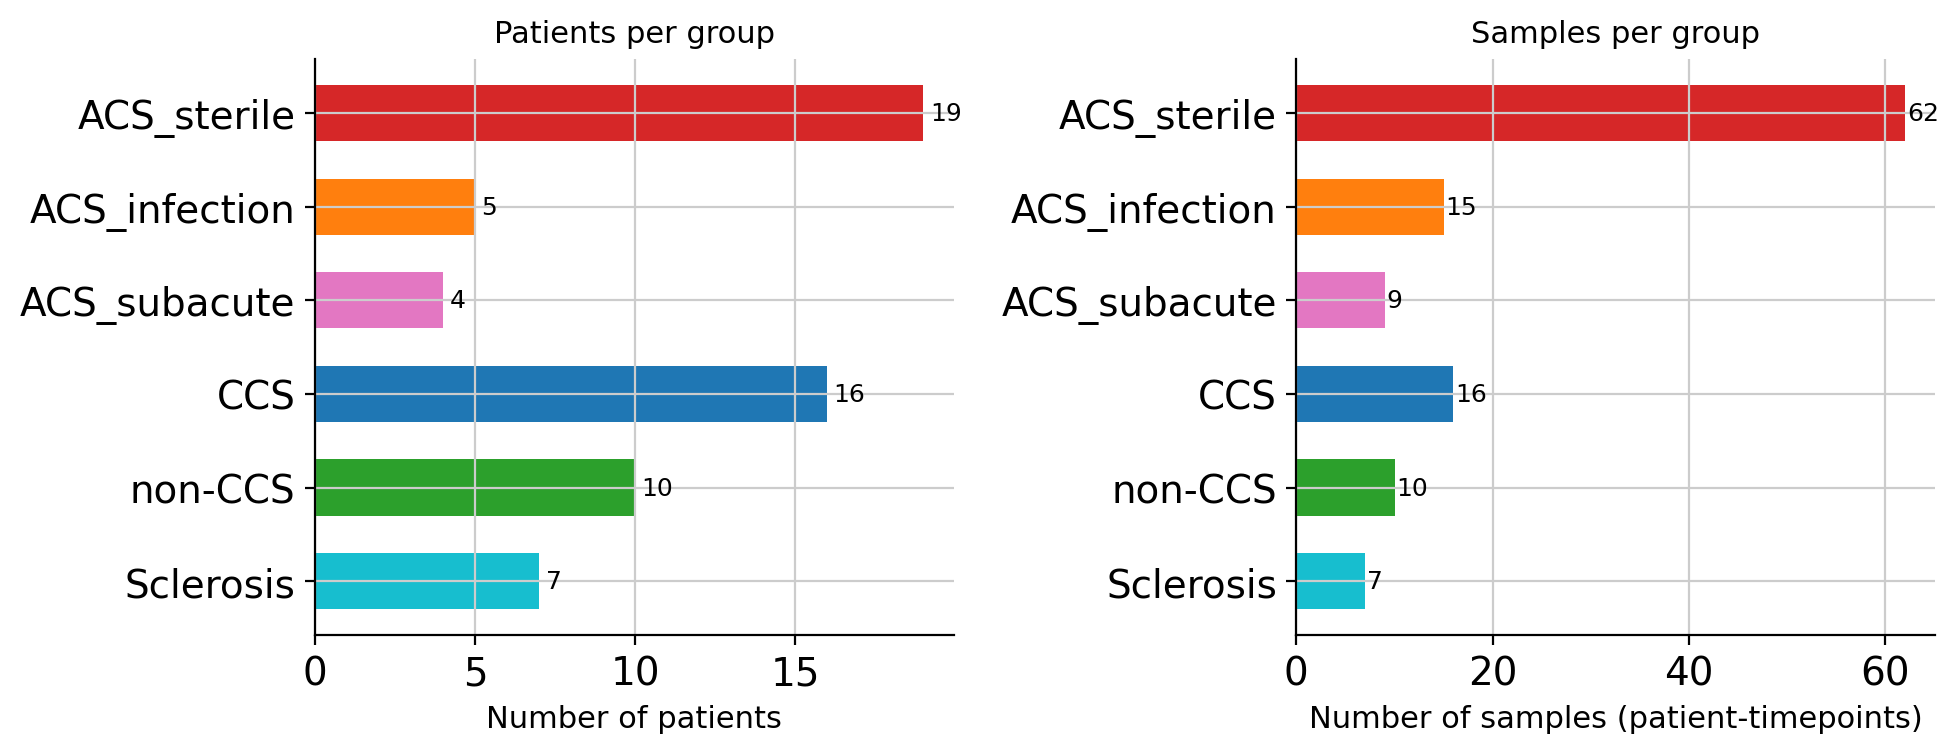

In [8]:
# ── Plot 3: Cohort overview bar chart (patients and cells per group) ──────────
obs_pt = adata.obs.drop_duplicates("display_name")
summary = obs_pt.groupby("condition").agg(
    patients=("display_name", lambda x: adata.obs.loc[adata.obs["display_name"].isin(x), "display_name"]
              .apply(lambda d: str(d).split(".")[0]).nunique()),
    samples=("display_name", "count"),
).reindex(condition_order)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bar_colors = [colors_cond[c] for c in summary.index]

axes[0].barh(summary.index, summary["patients"], color=bar_colors, height=0.6)
axes[0].set_xlabel("Number of patients", fontsize=11)
axes[0].set_title("Patients per group", fontsize=11)
axes[0].invert_yaxis()
axes[0].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(summary["patients"]):
    axes[0].text(v + 0.2, i, str(v), va="center", fontsize=9)

axes[1].barh(summary.index, summary["samples"], color=bar_colors, height=0.6)
axes[1].set_xlabel("Number of samples (patient-timepoints)", fontsize=11)
axes[1].set_title("Samples per group", fontsize=11)
axes[1].invert_yaxis()
axes[1].spines[["top", "right"]].set_visible(False)
for i, v in enumerate(summary["samples"]):
    axes[1].text(v + 0.2, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cohort_overview.png"), bbox_inches="tight", dpi=150)
plt.show()

## Step 2 — Pseudobulk aggregation\n",
    "\n",
    "Following the sc-best-practices tutorial: aggregate raw counts per (patient × cell type).  \n",
    "Each resulting row is one patient's summed counts for one cell type — the correct statistical unit for DESeq2."

In [9]:
def get_pseudobulk(adata, sample_col, groups_col, layer="counts", min_cells=10, min_counts=1000):
    """
    Aggregate raw counts per (sample, cell_type) by summing, via decoupler.
    Returns an AnnData where each obs is one (sample, cell_type) pseudobulk sample,
    already filtered to units with >= min_cells contributing cells and >= min_counts
    total counts (decoupler's dc.pp.filter_samples).
    """
    pdata = dc.pp.pseudobulk(adata, sample_col=sample_col, groups_col=groups_col, layer=layer, mode="sum")
    dc.pp.filter_samples(pdata, min_cells=min_cells, min_counts=min_counts)
    return pdata


def filter_by_expr(pdata, group, min_count=10, min_total_count=15):
    """Genes with sufficiently large counts to retain, via decoupler's edgeR-style filterByExpr."""
    return dc.pp.filter_by_expr(pdata, group=group, min_count=min_count,
                                min_total_count=min_total_count, inplace=False)


print("Pseudobulk aggregation functions ready (decoupler-backed).")

Pseudobulk aggregation functions ready (decoupler-backed).


In [ ]:
# QC: library sizes per pseudobulk sample (low-count samples can skew DESeq2)
def plot_pseudobulk_qc(pdata, condition_col, title_suffix, save_path):
    total_counts = pdata.X.sum(axis=1) if not issparse(pdata.X) else pdata.X.sum(axis=1).A1

    # .astype(str) avoids a pandas Categorical.map() quirk: mapping a categorical
    # column through a dict of RGB tuples makes pandas build a MultiIndex from the
    # tuple results, which then crashes checking that MultiIndex for NaNs.
    condition_vals = pdata.obs[condition_col].astype(str)
    colors = condition_vals.map(
        {c: col for c, col in zip(condition_vals.unique(), plt.cm.Set2.colors)}
    )
    fig, ax = plt.subplots(figsize=(max(10, pdata.n_obs * 0.25), 4))
    ax.bar(range(pdata.n_obs), sorted(total_counts), color=list(colors[np.argsort(total_counts)]))
    ax.set_xlabel("Pseudobulk sample (sorted by size)")
    ax.set_ylabel("Total counts")
    ax.set_title(f"Pseudobulk library sizes, QC ({title_suffix})")
    handles = [plt.Rectangle((0, 0), 1, 1, color=plt.cm.Set2.colors[i])
               for i, c in enumerate(condition_vals.unique())]
    ax.legend(handles, condition_vals.unique(), title="Condition", frameon=False)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


print("QC plotting function ready.")

## Step 3 — PyDESeq2 helper

For each cell type, subset the pseudobulk object to the two groups, filter low-expressed genes,
and run DESeq2. Positive log2FC = higher in `group_a` vs `group_b`.

In [11]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds  import DeseqStats


def run_deseq2_per_celltype(pdata, condition_col, group_a, group_b,
                             cell_type_col, min_samples=3, n_cpus=4,
                             covariate_col=None):
    """
    Run PyDESeq2 for group_a vs group_b for each cell type.
    Positive log2FC = higher in group_a vs group_b (group_b is reference).

    If `covariate_col` is given, it's added to the design as a blocking factor
    (e.g. patient_id) to account for repeated measures within the same patient
    when a group can contain more than one sample per patient.
    """
    results = {}

    for ct in sorted(pdata.obs[cell_type_col].unique()):
        mask = (
            (pdata.obs[cell_type_col] == ct) &
            (pdata.obs[condition_col].isin([group_a, group_b]))
        )
        pdata_ct = pdata[mask].copy()

        n_a = (pdata_ct.obs[condition_col] == group_a).sum()
        n_b = (pdata_ct.obs[condition_col] == group_b).sum()

        if n_a < min_samples or n_b < min_samples:
            print(f"  SKIP {ct}: {group_a}={n_a}, {group_b}={n_b} (need ≥{min_samples})")
            continue

        print(f"  {ct}: {group_a}={n_a}, {group_b}={n_b} samples")

        # Filter lowly expressed genes
        genes_to_keep = filter_by_expr(pdata_ct, group=condition_col,
                                       min_count=10, min_total_count=15)
        pdata_ct = pdata_ct[:, genes_to_keep].copy()

        X = pdata_ct.X if not issparse(pdata_ct.X) else pdata_ct.X.toarray()
        counts_df = pd.DataFrame(X.astype(int),
                                 index=pdata_ct.obs_names,
                                 columns=pdata_ct.var_names)

        meta_cols = [condition_col] if covariate_col is None else [covariate_col, condition_col]
        meta_df = pdata_ct.obs[meta_cols].copy()
        meta_df[condition_col] = pd.Categorical(
            meta_df[condition_col],
            categories=[group_b, group_a],  # group_b = reference level
        )
        design_factors = condition_col if covariate_col is None else [covariate_col, condition_col]

        try:
            dds = DeseqDataSet(
                counts=counts_df,
                metadata=meta_df,
                design_factors=design_factors,
                n_cpus=n_cpus,
            )
            dds.deseq2()
            stat_res = DeseqStats(
                dds,
                contrast=[condition_col, group_a, group_b],  # explicit contrast required
                n_cpus=n_cpus,
            )
            stat_res.summary()
            res = stat_res.results_df.copy()
            res["cell_type"] = ct
            results[ct] = res
        except Exception as e:
            print(f"    ERROR in {ct}: {e}")

    return results


print("PyDESeq2 ready.")

PyDESeq2 ready.


## Step 4 — Comparison pipeline

For each cell-type grouping (Harmony_leiden, Harmony_named, DRVI_leiden, DRVI_named), run the same three comparisons on the pseudobulk data:

1. **ACS vs CCS** — sterile ACS, **all timepoints (TP1M–TP4M)** vs CCS (TP0M), matching the paper's IAI comparison. Blocked by `patient_id` to avoid pseudoreplication from ACS patients contributing up to 4 correlated samples.
2. **ACS vs non-CCS** — sterile ACS (TP1M) vs non-CCS + Sclerosis, pooled as "Control". Not a comparison the paper makes.
3. **ACS longitudinal: TP1M vs TP4M** — paired within-patient design (`~ patient_id + timepoint`), sterile ACS only.

Defined once as a function below; called per cell-type grouping in Step 8. Note: `Harmony_leiden` (25 clusters) and `DRVI_leiden` (32 clusters) are much finer than their named-type counterparts — expect some smaller clusters to be skipped for not meeting the minimum sample/cell thresholds.

In [12]:
def run_all_comparisons(adata, cell_type_col, method_name):
    """Run the three DESeq2 comparisons (ACS vs CCS, ACS vs non-CCS, ACS longitudinal)
    for the given cell-type annotation column. Returns a dict of the three results dicts."""

    # ── Comparison 1 — ACS (all timepoints) vs CCS ───────────────────────────
    # Pools sterile ACS across TP1M-TP4M, matching the paper's IAI comparison
    # (which uses all 4 ACS timepoints vs CCS). Since this means some patients
    # contribute up to 4 correlated pseudobulk samples while CCS patients only
    # contribute 1, patient_id is added as a blocking covariate to avoid
    # pseudoreplication (~ patient_id + condition), same principle as Comparison 3.
    print(f"\n{'='*70}\n{method_name}: Comparison 1 — ACS (TP1M-TP4M) vs CCS\n{'='*70}")
    mask = (
        ((adata.obs["condition"] == "ACS_sterile") & (adata.obs["timepoint"].isin(["TP1M", "TP2M", "TP3M", "TP4M"]))) |
        (adata.obs["condition"] == "CCS")
    )
    adata_sub = adata[mask].copy()
    adata_sub.obs["patient_id"] = adata_sub.obs["display_name"].apply(lambda x: str(x).split(".")[0])
    print(f"ACS sterile (all timepoints) vs CCS — {adata_sub.n_obs:,} cells")
    print(adata_sub.obs["condition"].value_counts().to_string())
    print(f"ACS patients: {adata_sub.obs.loc[adata_sub.obs['condition'] == 'ACS_sterile', 'patient_id'].nunique()}, "
          f"CCS patients: {adata_sub.obs.loc[adata_sub.obs['condition'] == 'CCS', 'patient_id'].nunique()}")

    pdata_acs_ccs = get_pseudobulk(adata_sub, sample_col=SAMPLE_COL,
                                    groups_col=cell_type_col, layer="counts", min_cells=10)
    print(f"\nPseudobulk samples: {pdata_acs_ccs.n_obs}")
    plot_pseudobulk_qc(pdata_acs_ccs, condition_col="condition",
                        title_suffix=f"{method_name}, ACS vs CCS",
                        save_path=os.path.join(OUTPUT_DIR, f"pseudobulk_qc_{method_name}_ACS_vs_CCS.png"))

    results_acs_ccs = run_deseq2_per_celltype(
        pdata_acs_ccs, condition_col="condition",
        group_a="ACS_sterile", group_b="CCS", cell_type_col=cell_type_col,
        covariate_col="patient_id",
    )

    # ── Comparison 2 — ACS vs non-CCS ────────────────────────────────────────
    print(f"\n{'='*70}\n{method_name}: Comparison 2 — ACS vs non-CCS\n{'='*70}")
    mask = (
        ((adata.obs["condition"] == "ACS_sterile") & (adata.obs["timepoint"] == "TP1M")) |
        (adata.obs["condition"].isin(["non-CCS", "Sclerosis"]))
    )
    adata_sub = adata[mask].copy()
    adata_sub.obs["condition2"] = adata_sub.obs["condition"].replace(
        {"non-CCS": "Control", "Sclerosis": "Control"}
    )
    print(f"ACS sterile (TP1M) vs Control — {adata_sub.n_obs:,} cells")
    print(adata_sub.obs["condition2"].value_counts().to_string())

    pdata_acs_ctrl = get_pseudobulk(adata_sub, sample_col=SAMPLE_COL,
                                     groups_col=cell_type_col, layer="counts", min_cells=10)
    print(f"\nPseudobulk samples: {pdata_acs_ctrl.n_obs}")
    plot_pseudobulk_qc(pdata_acs_ctrl, condition_col="condition2",
                        title_suffix=f"{method_name}, ACS vs non-CCS",
                        save_path=os.path.join(OUTPUT_DIR, f"pseudobulk_qc_{method_name}_ACS_vs_nonCCS.png"))

    results_acs_nonccs = run_deseq2_per_celltype(
        pdata_acs_ctrl, condition_col="condition2",
        group_a="ACS_sterile", group_b="Control", cell_type_col=cell_type_col,
    )

    # ── Comparison 3 — ACS longitudinal: TP1M vs TP4M ────────────────────────
    print(f"\n{'='*70}\n{method_name}: Comparison 3 — ACS longitudinal TP1M vs TP4M\n{'='*70}")
    mask_long = (
        (adata.obs["condition"] == "ACS_sterile") &
        (adata.obs["timepoint"].isin(["TP1M", "TP4M"]))
    )
    adata_long = adata[mask_long].copy()
    adata_long.obs["patient_id"] = adata_long.obs["display_name"].apply(
        lambda x: str(x).split(".")[0]
    )
    print(f"ACS sterile TP1M vs TP4M — {adata_long.n_obs:,} cells")
    print(adata_long.obs["timepoint"].value_counts().to_string())
    print(f"\nPatients: {adata_long.obs['patient_id'].nunique()}")

    pdata_long = get_pseudobulk(adata_long, sample_col=SAMPLE_COL,
                                 groups_col=cell_type_col, layer="counts", min_cells=10)
    print(f"\nPseudobulk samples: {pdata_long.n_obs}")
    plot_pseudobulk_qc(pdata_long, condition_col="timepoint",
                        title_suffix=f"{method_name}, ACS TP1M vs TP4M",
                        save_path=os.path.join(OUTPUT_DIR, f"pseudobulk_qc_{method_name}_ACS_TP1M_vs_TP4M.png"))

    # Paired DESeq2: patient_id as covariate, timepoint as the tested factor
    # design: ~ patient_id + timepoint  (controls for per-patient baseline differences)
    results_longitudinal = {}

    for ct in sorted(pdata_long.obs[cell_type_col].unique()):
        mask_ct = pdata_long.obs[cell_type_col] == ct
        pdata_ct = pdata_long[mask_ct].copy()

        n_tp1 = (pdata_ct.obs["timepoint"] == "TP1M").sum()
        n_tp4 = (pdata_ct.obs["timepoint"] == "TP4M").sum()

        if n_tp1 < 3 or n_tp4 < 3:
            print(f"  SKIP {ct}: TP1M={n_tp1}, TP4M={n_tp4} (need ≥3)")
            continue

        # Keep only patients with both timepoints present (required for paired design)
        patients_tp1 = set(pdata_ct.obs.loc[pdata_ct.obs["timepoint"] == "TP1M", "patient_id"])
        patients_tp4 = set(pdata_ct.obs.loc[pdata_ct.obs["timepoint"] == "TP4M", "patient_id"])
        paired_patients = patients_tp1 & patients_tp4
        pdata_ct = pdata_ct[pdata_ct.obs["patient_id"].isin(paired_patients)].copy()

        if pdata_ct.obs["patient_id"].nunique() < 3:
            print(f"  SKIP {ct}: only {pdata_ct.obs['patient_id'].nunique()} paired patients")
            continue

        print(f"  {ct}: {pdata_ct.obs['patient_id'].nunique()} paired patients")

        genes_to_keep = filter_by_expr(pdata_ct, group="timepoint",
                                       min_count=10, min_total_count=15)
        pdata_ct = pdata_ct[:, genes_to_keep].copy()

        X = pdata_ct.X if not issparse(pdata_ct.X) else pdata_ct.X.toarray()
        counts_df = pd.DataFrame(X.astype(int),
                                 index=pdata_ct.obs_names,
                                 columns=pdata_ct.var_names)

        meta_df = pdata_ct.obs[["patient_id", "timepoint"]].copy()
        meta_df["timepoint"] = pd.Categorical(meta_df["timepoint"],
                                              categories=["TP4M", "TP1M"])

        try:
            dds = DeseqDataSet(
                counts=counts_df,
                metadata=meta_df,
                design_factors=["patient_id", "timepoint"],  # paired design
                n_cpus=4,
            )
            dds.deseq2()
            stat_res = DeseqStats(
                dds,
                contrast=["timepoint", "TP1M", "TP4M"],
                n_cpus=4,
            )
            stat_res.summary()
            res = stat_res.results_df.copy()
            res["cell_type"] = ct
            results_longitudinal[ct] = res
        except Exception as e:
            print(f"    ERROR in {ct}: {e}")

    return {
        "ACS_vs_CCS": results_acs_ccs,
        "ACS_vs_nonCCS": results_acs_nonccs,
        "ACS_TP1M_vs_TP4M": results_longitudinal,
    }


print("Comparison pipeline function ready.")

Comparison pipeline function ready.


## Step 5 — Volcano plots

In [13]:
def volcano_panel(results_dict, title, padj_thresh=0.05, lfc_thresh=1.0,
                  top_n=8, save=None):
    if not results_dict:
        print(f"No results for: {title}")
        return

    cell_types = list(results_dict.keys())
    n = len(cell_types)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, ct in zip(axes, cell_types):
        df = results_dict[ct].dropna(subset=["log2FoldChange", "padj"]).copy()
        df["-log10padj"] = -np.log10(df["padj"].clip(lower=1e-300))

        sig_up   = (df["padj"] < padj_thresh) & (df["log2FoldChange"] >  lfc_thresh)
        sig_down = (df["padj"] < padj_thresh) & (df["log2FoldChange"] < -lfc_thresh)
        ns       = ~(sig_up | sig_down)

        ax.scatter(df.loc[ns,       "log2FoldChange"], df.loc[ns,       "-log10padj"],
                   color="lightgrey", s=5, alpha=0.5, rasterized=True)
        ax.scatter(df.loc[sig_up,   "log2FoldChange"], df.loc[sig_up,   "-log10padj"],
                   color="#d62728", s=10, alpha=0.8, label=f"up ({sig_up.sum()})")
        ax.scatter(df.loc[sig_down, "log2FoldChange"], df.loc[sig_down, "-log10padj"],
                   color="#1f77b4", s=10, alpha=0.8, label=f"down ({sig_down.sum()})")

        ax.axhline(-np.log10(padj_thresh), color="black", linestyle="--", linewidth=0.7)
        ax.axvline( lfc_thresh,  color="black", linestyle="--", linewidth=0.7)
        ax.axvline(-lfc_thresh,  color="black", linestyle="--", linewidth=0.7)

        # Label top genes by padj
        top = df[sig_up | sig_down].nsmallest(top_n, "padj")
        for _, row in top.iterrows():
            ax.text(row["log2FoldChange"], row["-log10padj"],
                    row.name, fontsize=6, ha="center", va="bottom")

        ax.set_xlabel("log$_2$ Fold Change", fontsize=10)
        ax.set_ylabel("-log$_{10}$(padj)", fontsize=10)
        ax.set_title(ct, fontsize=10)
        ax.legend(fontsize=8, frameon=False)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight", dpi=150)
    plt.show()

print("Volcano function ready.")

Volcano function ready.


## Step 6 — Summary tables

In [14]:
def summarise(results_dict, label, padj_thresh=0.05, lfc_thresh=1.0):
    if not results_dict:
        print(f"No results for {label}")
        return None

    all_res = pd.concat(results_dict.values())
    all_res["gene"] = all_res.index
    all_res["significant"] = (
        (all_res["padj"] < padj_thresh) &
        (all_res["log2FoldChange"].abs() > lfc_thresh)
    )

    sig = all_res[all_res["significant"]]
    fname = label.replace(" ", "_") + ".csv"
    all_res.to_csv(os.path.join(OUTPUT_DIR, fname), index=False)

    print(f"{label}")
    print(f"Significant DEGs (padj<{padj_thresh}, |LFC|>{lfc_thresh}): {len(sig)}")
    if not sig.empty:
        print(sig.groupby("cell_type").size().sort_values(ascending=False).to_string())
    return all_res


print("Summary function ready.")

Summary function ready.


## Step 7 — Heatmap: top DEGs across cell types

In [ ]:
def heatmap_top_degs(res, label, top_per_ct=3, save=None):
    if res is None:
        return
    sig = res[res["significant"]].copy()
    if sig.empty:
        print(f"No significant DEGs for {label}")
        return

    top_genes = (
        sig.sort_values("padj")
           .groupby("cell_type")
           .head(top_per_ct)["gene"]
           .unique()
    )
    pivot = (
        sig[sig["gene"].isin(top_genes)]
           .pivot_table(index="gene", columns="cell_type",
                        values="log2FoldChange", aggfunc="mean")
           .fillna(0)
    )
    vmax = np.abs(pivot.values).max()

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.3),
                                    max(5, len(pivot.index) * 0.35)))
    sns.heatmap(pivot, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                linewidths=0.4, ax=ax,
                cbar_kws={"label": f"log2FC ({label})"})
    ax.set_title(f"Top DEGs per cell type, {label}", fontsize=12)
    ax.set_xlabel("Cell type"); ax.set_ylabel("Gene")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches="tight", dpi=150)
    plt.show()


print("Heatmap function ready.")

## Step 8 — Run the full pipeline for each cell-type grouping

For each of Harmony_leiden, Harmony_named, DRVI_leiden and DRVI_named: build pseudobulk, run the three comparisons, plot pseudobulk QC and volcano plots, write summary CSVs, and plot top-DEG heatmaps. Outputs are written to `OUTPUT_DIR` with the grouping name in the filename so results can be compared side by side.

In [ ]:
all_results = {}

for method_name, cell_type_col in CELL_TYPE_COLS.items():
    print(f"\n\n{'#'*70}\n# {method_name}  (cell_type_col = '{cell_type_col}')\n{'#'*70}")

    results = run_all_comparisons(adata, cell_type_col, method_name)
    all_results[method_name] = results

    volcano_panel(
        results["ACS_vs_CCS"],
        title=f"{method_name}: ACS vs CCS, pseudobulk DEG per cell type",
        padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH,
        save=os.path.join(OUTPUT_DIR, f"volcano_{method_name}_ACS_vs_CCS.png"),
    )
    volcano_panel(
        results["ACS_vs_nonCCS"],
        title=f"{method_name}: ACS vs non-CCS, pseudobulk DEG per cell type",
        padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH,
        save=os.path.join(OUTPUT_DIR, f"volcano_{method_name}_ACS_vs_nonCCS.png"),
    )
    volcano_panel(
        results["ACS_TP1M_vs_TP4M"],
        title=f"{method_name}: ACS TP1M vs TP4M, pseudobulk DEG per cell type",
        padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH,
        save=os.path.join(OUTPUT_DIR, f"volcano_{method_name}_ACS_TP1M_vs_TP4M.png"),
    )

    res_acs_ccs    = summarise(results["ACS_vs_CCS"],       f"{method_name}_ACS_vs_CCS",       padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH)
    res_acs_nonccs = summarise(results["ACS_vs_nonCCS"],    f"{method_name}_ACS_vs_nonCCS",    padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH)
    res_long       = summarise(results["ACS_TP1M_vs_TP4M"], f"{method_name}_ACS_TP1M_vs_TP4M", padj_thresh=PADJ_THRESH, lfc_thresh=LFC_THRESH)

    for label, res in [("ACS vs CCS", res_acs_ccs),
                       ("ACS vs Control", res_acs_nonccs),
                       ("ACS TP1M vs TP4M", res_long)]:
        if res is None:
            continue
        sig = res[res["significant"]]
        if sig.empty:
            print(f"{method_name}, {label}: no significant DEGs at current thresholds")
            continue
        top = (
            sig.sort_values("padj")
               .groupby("cell_type")
               .head(5)[["cell_type", "gene", "log2FoldChange", "padj", "baseMean"]]
        )
        top["log2FoldChange"] = top["log2FoldChange"].round(2)
        top["padj"] = top["padj"].apply(lambda x: f"{x:.2e}")
        top["baseMean"] = top["baseMean"].round(1)
        print(f"\n{method_name}, {label}, top 5 DEGs per cell type")
        display(top.reset_index(drop=True))

    heatmap_top_degs(res_acs_ccs,    f"{method_name}: ACS vs CCS",
                     save=os.path.join(OUTPUT_DIR, f"heatmap_{method_name}_ACS_vs_CCS.png"))
    heatmap_top_degs(res_acs_nonccs, f"{method_name}: ACS vs non-CCS",
                     save=os.path.join(OUTPUT_DIR, f"heatmap_{method_name}_ACS_vs_nonCCS.png"))
    heatmap_top_degs(res_long,       f"{method_name}: ACS TP1M vs TP4M",
                     save=os.path.join(OUTPUT_DIR, f"heatmap_{method_name}_ACS_TP1M_vs_TP4M.png"))

print(f"\n\nSignificant DEG counts per method (padj<{PADJ_THRESH}, |log2FC|>{LFC_THRESH}):")
for method_name in CELL_TYPE_COLS:
    for comparison in ["ACS_vs_CCS", "ACS_vs_nonCCS", "ACS_TP1M_vs_TP4M"]:
        fname = os.path.join(OUTPUT_DIR, f"{method_name}_{comparison}.csv")
        if os.path.exists(fname):
            df = pd.read_csv(fname)
            print(f"  {method_name:12s} {comparison:20s} {int(df['significant'].sum())} DEGs")

In [17]:
print("Done. Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

Done. Output files:
  DRVI_leiden_ACS_TP1M_vs_TP4M.csv
  DRVI_leiden_ACS_vs_CCS.csv
  DRVI_leiden_ACS_vs_nonCCS.csv
  DRVI_named_ACS_TP1M_vs_TP4M.csv
  DRVI_named_ACS_vs_CCS.csv
  DRVI_named_ACS_vs_nonCCS.csv
  Harmony_leiden_ACS_TP1M_vs_TP4M.csv
  Harmony_leiden_ACS_vs_CCS.csv
  Harmony_leiden_ACS_vs_nonCCS.csv
  Harmony_named_ACS_TP1M_vs_TP4M.csv
  Harmony_named_ACS_vs_CCS.csv
  Harmony_named_ACS_vs_nonCCS.csv
  celltype_composition.png
  cohort_overview.png
  heatmap_DRVI_leiden_ACS_TP1M_vs_TP4M.png
  heatmap_DRVI_leiden_ACS_vs_CCS.png
  heatmap_DRVI_leiden_ACS_vs_nonCCS.png
  heatmap_DRVI_named_ACS_TP1M_vs_TP4M.png
  heatmap_DRVI_named_ACS_vs_CCS.png
  heatmap_DRVI_named_ACS_vs_nonCCS.png
  heatmap_Harmony_leiden_ACS_TP1M_vs_TP4M.png
  heatmap_Harmony_leiden_ACS_vs_CCS.png
  heatmap_Harmony_leiden_ACS_vs_nonCCS.png
  heatmap_Harmony_named_ACS_TP1M_vs_TP4M.png
  heatmap_Harmony_named_ACS_vs_CCS.png
  heatmap_Harmony_named_ACS_vs_nonCCS.png
  pseudobulk_qc_DRVI_leiden_ACS_TP1M_vs_TP4